In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/video_games_cleaned.csv")

df.head()

,Name,Platform,Year_of_Release,Era,Genre,Publisher,Developer,Rating,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Global_Sales_Calculated,Sales_Region_Dominant,Critic_Score,Critic_Count,User_Score,User_Count,Score_Gap
0,Wii Sports,Wii,2006,2000s,Sports,Nintendo,Nintendo,E,41.36,28.96,3.77,8.45,82.53,82.54,NaN,76.0,51,8.0,322,-4.0
1,Super Mario Bros.,NES,1985,1980s,Platform,Nintendo,Unknown,Unknown,29.08,3.58,6.81,0.77,40.24,40.24,NaN,71.0,21,7.5,24,-4.0
2,Mario Kart Wii,Wii,2008,2000s,Racing,Nintendo,Nintendo,E,15.68,12.76,3.79,3.29,35.52,35.52,NaN,82.0,73,8.3,709,-1.0
3,Wii Sports Resort,Wii,2009,2000s,Sports,Nintendo,Nintendo,E,15.61,10.93,3.28,2.95,32.77,32.77,NaN,80.0,73,8.0,192,0.0
4,Pokemon Red/Pokemon Blue,GB,1996,1990s,Role-Playing,Nintendo,Unknown,Unknown,11.27,8.89,10.22,1.00,31.37,31.38,NaN,71.0,21,7.5,24,-4.0


In [2]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16713 entries, 0 to 16712
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Name                     16713 non-null  object 
 1   Platform                 16713 non-null  object 
 2   Year_of_Release          16713 non-null  int64  
 3   Era                      16713 non-null  object 
 4   Genre                    16713 non-null  object 
 5   Publisher                16713 non-null  object 
 6   Developer                16713 non-null  object 
 7   Rating                   16713 non-null  object 
 8   NA_Sales                 16713 non-null  float64
 9   EU_Sales                 16713 non-null  float64
 10  JP_Sales                 16713 non-null  float64
 11  Other_Sales              16713 non-null  float64
 12  Global_Sales             16713 non-null  float64
 13  Global_Sales_Calculated  16713 non-null  float64
 14  Sales_Region_Dominant 

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Global_Sales_Calculated,Critic_Score,Critic_Count,User_Score,User_Count,Score_Gap
count,16713.000000,16713.000000,16713.000000,16713.000000,16713.000000,16713.000000,16713.000000,16713.000000,16713.000000,16713.000000,16713.000000,16713.000000
mean,2006.494525,0.263302,0.145045,0.077625,0.047343,0.533568,0.533315,70.010531,23.610004,7.329719,86.775384,-3.286663
std,5.828405,0.813565,0.503359,0.308871,0.186742,1.548125,1.548282,9.778073,13.511741,1.027910,384.443989,10.250295
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,13.000000,3.000000,0.000000,4.000000,-62.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.060000,71.000000,21.000000,7.500000,24.000000,-4.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,0.170000,71.000000,21.000000,7.500000,24.000000,-4.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,0.470000,71.000000,21.000000,7.500000,24.000000,-2.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,82.530000,82.540000,98.000000,113.000000,9.700000,10665.000000,71.000000


In [3]:
df.isnull().sum()

Name                           0
Platform                       0
Year_of_Release                0
Era                            0
Genre                          0
Publisher                      0
Developer                      0
Rating                         0
NA_Sales                       0
EU_Sales                       0
JP_Sales                       0
Other_Sales                    0
Global_Sales                   0
Global_Sales_Calculated        0
Sales_Region_Dominant      10225
Critic_Score                   0
Critic_Count                   0
User_Score                     0
User_Count                     0
Score_Gap                      0
dtype: int64

Dataset contains 16k+ video game records across multiple platforms and regions.
Key metrics include regional sales, critic scores, and user engagement.

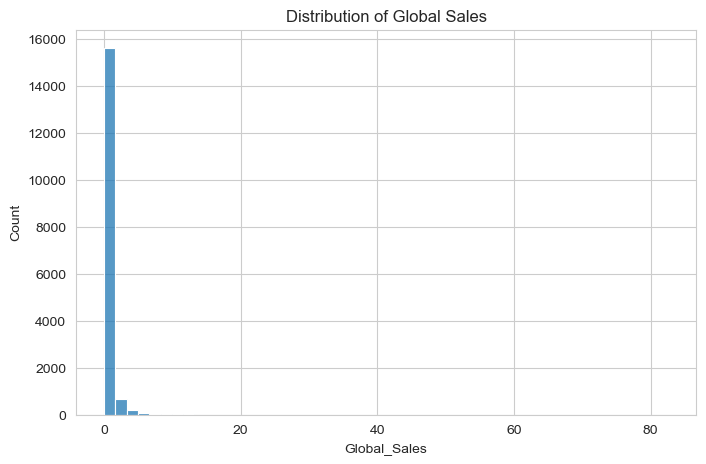

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["Global_Sales"], bins=50)
plt.title("Distribution of Global Sales")
plt.show()

Most games sell below 1 million units while only a few achieve blockbuster sales.

In [5]:
top_games = df.sort_values("Global_Sales", ascending=False).head(10)
top_games[["Name","Platform","Genre","Global_Sales"]]

,Name,Platform,Genre,Global_Sales
0,Wii Sports,Wii,Sports,82.53
1,Super Mario Bros.,NES,Platform,40.24
2,Mario Kart Wii,Wii,Racing,35.52
3,Wii Sports Resort,Wii,Sports,32.77
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37
5,Tetris,GB,Puzzle,30.26
6,New Super Mario Bros.,DS,Platform,29.80
7,Wii Play,Wii,Misc,28.92
8,New Super Mario Bros. Wii,Wii,Platform,28.32
9,Duck Hunt,NES,Shooter,28.31


Top selling games are dominated by Nintendo titles.

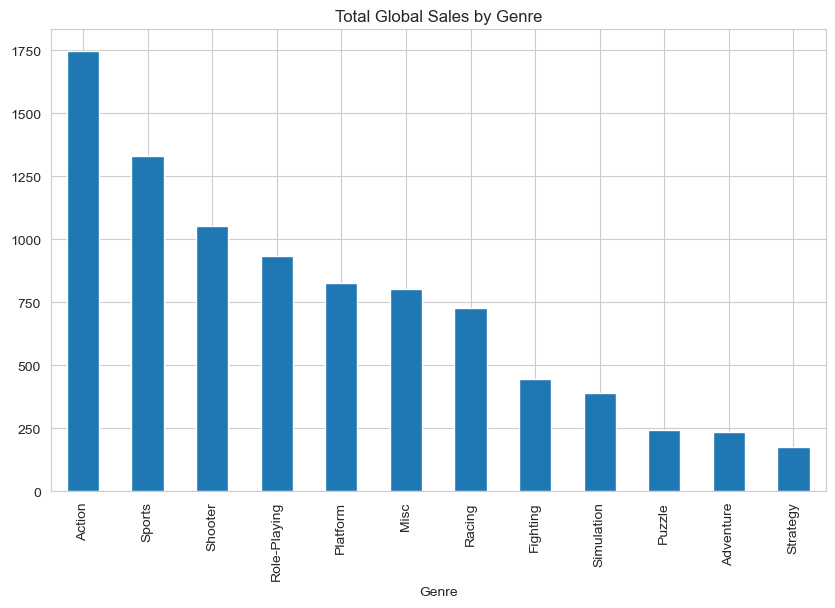

In [6]:
genre_sales = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
genre_sales.plot(kind="bar")
plt.title("Total Global Sales by Genre")
plt.show()

Action and Sports genres dominate global video game revenue.

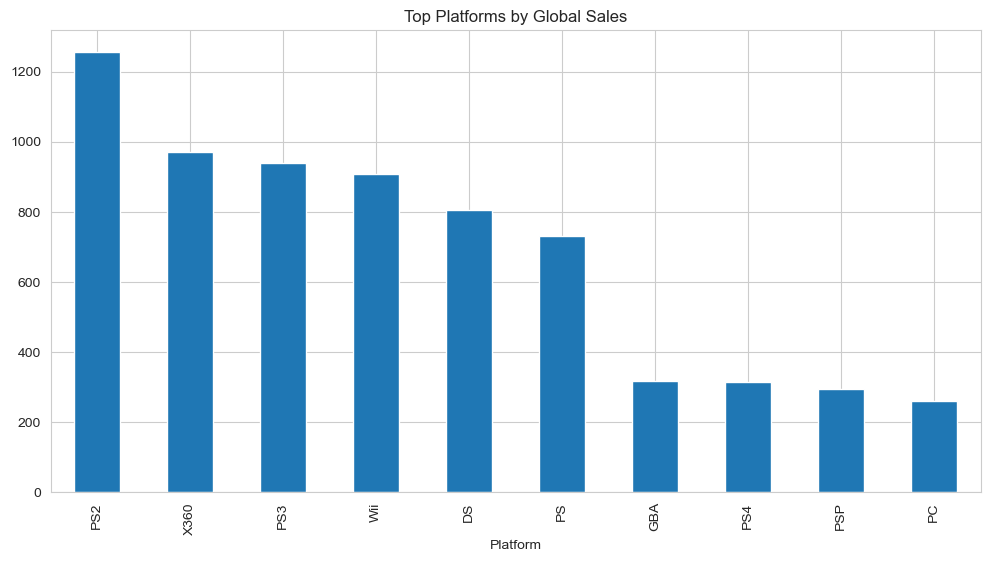

In [7]:
platform_sales = df.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
platform_sales.head(10).plot(kind="bar")
plt.title("Top Platforms by Global Sales")
plt.show()

Legacy consoles such as PS2 and Wii contributed significantly to total industry revenue.

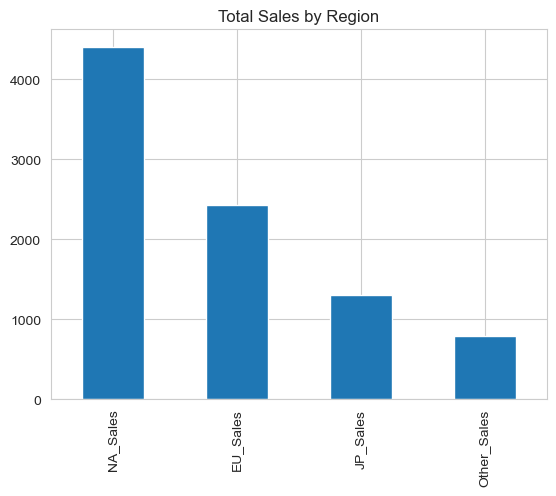

In [8]:
region_sales = df[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()

region_sales.plot(kind="bar")
plt.title("Total Sales by Region")
plt.show()

North America represents the largest gaming market.

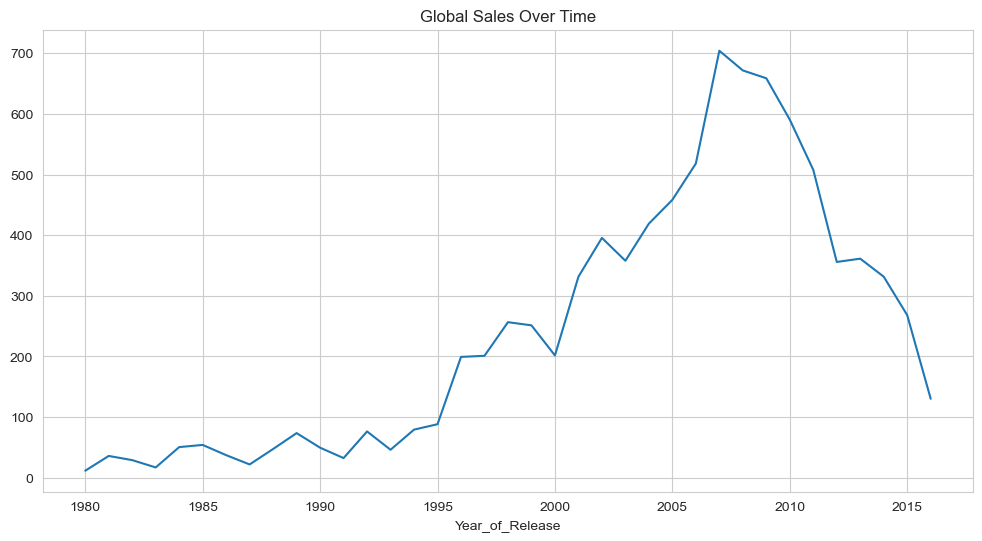

In [9]:
year_sales = df.groupby("Year_of_Release")["Global_Sales"].sum()

plt.figure(figsize=(12,6))
year_sales.plot()
plt.title("Global Sales Over Time")
plt.show()

The gaming industry experienced rapid growth between 2005–2010.

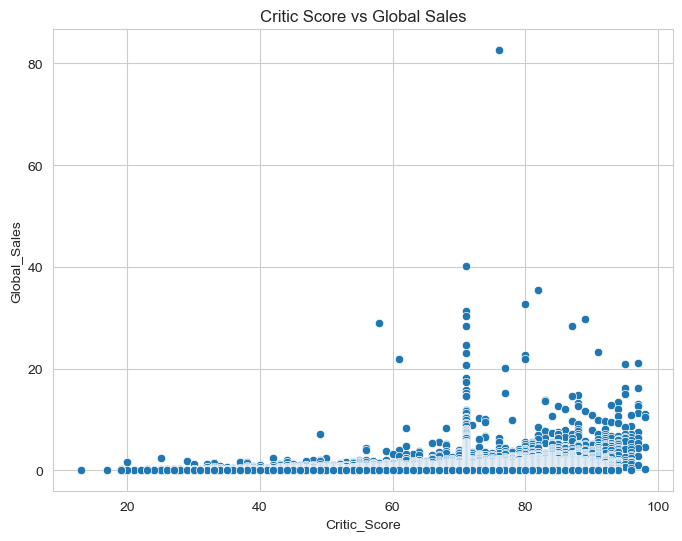

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Critic_Score", y="Global_Sales", data=df)
plt.title("Critic Score vs Global Sales")
plt.show()

Higher critic scores are generally associated with higher global sales.

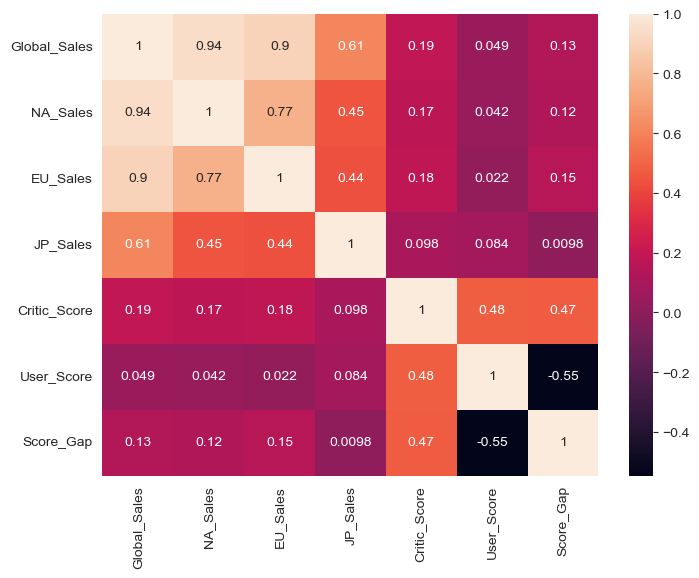

In [11]:
corr = df[
[
"Global_Sales",
"NA_Sales",
"EU_Sales",
"JP_Sales",
"Critic_Score",
"User_Score",
"Score_Gap"
]
].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

Regional sales are highly correlated with global sales.